# Customer Segmentation using PCA + K-Means

Using the Online Retail dataset from UCI (a UK based online gift shop, transactions from Dec 2010 to Dec 2011).

Goal is to group customers based on their buying behaviour so the business can target different types of customers differently (e.g. VIP customers vs one time buyers vs people who used to buy but stopped).

Steps:
1. clean the raw transaction data
2. build customer-level features (RFM style)
3. scale + PCA
4. K-Means clustering
5. figure out what each cluster actually means

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Step 1: Load the data and clean it up

The raw data is one row per item bought per invoice, not one row per customer. So first I need to clean it before I can even think about building customer level features.

things to remove:
- rows with no CustomerID (can't do customer segmentation without knowing who the customer is lol)
- cancelled orders (invoice numbers starting with C) - these are returns not actual purchases
- rows with negative or 0 quantity/price - probably data entry errors or something weird

In [2]:
df = pd.read_excel('data/Online_Retail.xlsx')
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# checking nulls first
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
# dropping rows with no customer id
print('before:', len(df))
df = df.dropna(subset=['CustomerID'])
print('after dropping missing CustomerID:', len(df))

before: 541909


after dropping missing CustomerID: 406829


In [5]:
# removing cancelled orders - these start with a 'C' in InvoiceNo
print('before:', len(df))
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print('after removing cancellations:', len(df))

before: 406829


after removing cancellations:

 397924


In [6]:
# also getting rid of weird rows with negative/zero qty or price
print('before:', len(df))
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print('after:', len(df))

df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print('final clean shape:', df.shape)
print('number of unique customers:', df['CustomerID'].nunique())

before: 397924


after: 397884
final clean shape: (397884, 9)
number of unique customers: 4338


## Step 2: Build customer-level features

Now I need to squish all these transaction rows into ONE row per customer. This is basically RFM (Recency, Frequency, Monetary) plus a few extra features I thought would be useful:

- Recency = how many days since they last bought something
- Frequency = how many separate orders they've placed
- Monetary = total money spent
- AvgOrderValue = spent / number of orders
- UniqueProducts = how many different products they've bought (variety)
- TotalItems = total quantity of items bought overall
- TenureDays = how long they've been a customer (since first purchase)

In [7]:
# setting a reference date to calculate recency from - one day after the last transaction in the whole dataset
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print('snapshot date:', snapshot_date)

snapshot date: 2011-12-10 12:50:00


In [8]:
customer_df = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary = ('TotalPrice', 'sum'),
    UniqueProducts = ('StockCode', 'nunique'),
    TotalItems = ('Quantity', 'sum')
).reset_index()

# avg order value needs a bit more work since its Monetary/Frequency
customer_df['AvgOrderValue'] = customer_df['Monetary'] / customer_df['Frequency']

customer_df.head()

,CustomerID,Recency,Frequency,Monetary,UniqueProducts,TotalItems,AvgOrderValue
0,12346,326,1,77183.60,1,74215,77183.600000
1,12347,2,7,4310.00,103,2458,615.714286
2,12348,75,4,1797.24,22,2341,449.310000
3,12349,19,1,1757.55,73,631,1757.550000
4,12350,310,1,334.40,17,197,334.400000


In [9]:
# tenure - days since their very first purchase
first_purchase = df.groupby('CustomerID')['InvoiceDate'].min()
customer_df['TenureDays'] = customer_df['CustomerID'].map(lambda c: (snapshot_date - first_purchase[c]).days)

print(customer_df.shape)
customer_df.describe()

(4338, 8)


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,TotalItems,AvgOrderValue,TenureDays
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460,61.501153,1191.289073,419.166289,223.308207
std,1721.808492,100.014169,7.697998,8989.230441,85.366768,5046.081546,1796.537944,117.886471
min,12346.000000,1.000000,1.000000,3.750000,1.000000,1.000000,3.450000,1.000000
25%,13813.250000,18.000000,1.000000,307.415000,16.000000,160.000000,178.625000,113.000000
50%,15299.500000,51.000000,2.000000,674.485000,35.000000,379.000000,293.900000,249.000000
75%,16778.750000,142.000000,5.000000,1661.740000,77.000000,992.750000,430.113750,327.000000
max,18287.000000,374.000000,209.000000,280206.020000,1787.000000,196915.000000,84236.250000,374.000000


Ok so looking at the describe() output, the Monetary and Frequency columns have a HUGE range. Like the max monetary value is way way higher than the mean. That's probably some big spender/wholesale customer messing with the average. Keep this in mind for later, might need to fix this before clustering.

## Step 3: Scale the features (and fix the skew problem)

Before I do PCA + KMeans I need to scale everything since these algorithms use distance and if one feature is in the range of thousands (like Monetary) and another is 0-1 it'll just dominate everything.

But first — I actually tried running this WITHOUT fixing the skew first (just straight up StandardScaler) and it gave me a really weird result: one "cluster" had literally 17 people in it who were spending insane amounts of money. Turns out those are probably wholesale/bulk buyers mixed into the retail data, and because their numbers are SO much bigger than everyone else, they were dragging the whole clustering around.

Fix = log transform the skewed columns first (log1p so it handles 0s fine), THEN scale. This is apparently pretty standard for this kind of RFM data since spend/frequency numbers are almost always right-skewed like this.

In [10]:
skewed_cols = ['Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'TotalItems']
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'TotalItems', 'TenureDays']

df_for_scaling = customer_df.copy()
for col in skewed_cols:
    df_for_scaling[col] = np.log1p(df_for_scaling[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_for_scaling[feature_cols])

print(X_scaled.shape)

(4338, 7)


## Step 4: PCA

Reducing down to fewer dimensions so its easier to cluster and visualize. Going with 3 components.

In [11]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('variance explained by each component:', pca.explained_variance_ratio_)
print('total variance explained:', sum(pca.explained_variance_ratio_))

variance explained by each component: [0.57480667 0.1848623  0.14188779]
total variance explained: 0.9015567666315665


~90% variance explained with just 3 components instead of 7 original features, so we're not losing much info here.

## Step 5: Figure out how many clusters (K)

Using elbow method (plot inertia vs K, look for where it stops dropping fast) and silhouette score as a double check.

In [12]:
inertia_list = []
silhouette_list = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(X_pca, cluster_labels))
    print(f'k={k}  inertia={kmeans.inertia_:.0f}  silhouette={silhouette_list[-1]:.3f}')

k=2  inertia=15951  silhouette=0.358
k=3  inertia=12115  silhouette=0.340


k=4  inertia=9906  silhouette=0.301
k=5  inertia=8444  silhouette=0.298


k=6  inertia=7455  silhouette=0.299


k=7  inertia=6673  silhouette=0.286


k=8  inertia=6049  silhouette=0.280


k=9  inertia=5608  silhouette=0.276


k=10  inertia=5263  silhouette=0.267


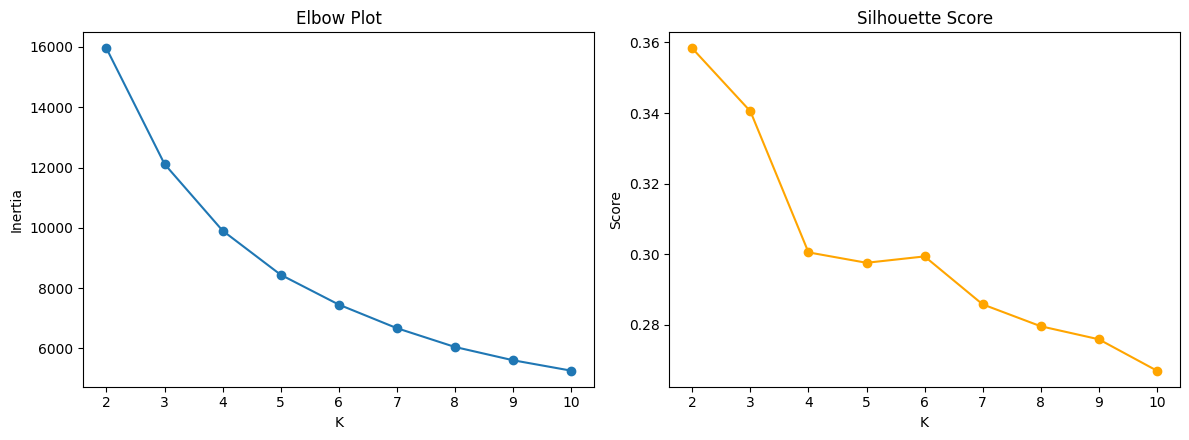

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.5))

ax[0].plot(range(2,11), inertia_list, marker='o')
ax[0].set_title('Elbow Plot')
ax[0].set_xlabel('K')
ax[0].set_ylabel('Inertia')

ax[1].plot(range(2,11), silhouette_list, marker='o', color='orange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('K')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

Going with **K=4**. Not the absolute highest silhouette score (K=2 technically wins there) but K=2 is basically just splitting "everyone" vs a tiny outlier-ish group, not actually useful for the business. K=4 is where the elbow flattens out and silhouette stays pretty stable (~0.3) so I'm going with that — gives interpretable groups instead of an overly simple split.

In [14]:
kmeans_final = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels = kmeans_final.fit_predict(X_pca)

print('silhouette score for final model:', silhouette_score(X_pca, labels))

silhouette score for final model: 0.3005535014751073


## Step 6: Plot the clusters

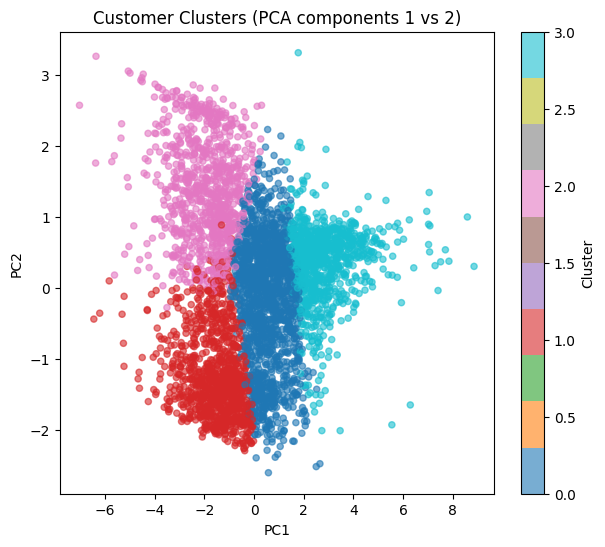

In [15]:
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', alpha=0.6, s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Clusters (PCA components 1 vs 2)')
plt.colorbar(label='Cluster')
plt.show()

## Step 7: What do these clusters actually mean?

Numbers don't mean much on their own, gotta look at the actual (real scale, not log/scaled) feature values per cluster to understand who's in each group.

In [16]:
customer_df['Cluster'] = labels

cluster_summary = customer_df.groupby('Cluster')[feature_cols].mean().round(1)
cluster_summary['num_customers'] = customer_df.groupby('Cluster').size()
cluster_summary['pct'] = (cluster_summary['num_customers'] / len(customer_df) * 100).round(1)
cluster_summary

,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalItems,TenureDays,num_customers,pct
Cluster,,,,,,,,,
0,63.9,3.2,1176.7,451.4,58.9,696.5,226.7,1517,35.0
1,52.4,1.4,311.5,246.5,22.2,191.1,77.0,1024,23.6
2,253.6,1.4,302.9,233.6,17.9,164.0,283.9,889,20.5
3,27.9,12.0,7200.6,741.8,153.0,4151.7,323.3,908,20.9


Based on the numbers above:

- **Cluster 0** — medium recency, buys a few times a year, moderate spend. Basically your regular, reliable customers.
- **Cluster 1** — pretty new customers (low tenure), haven't ordered much yet. Probably still deciding if they like the shop.
- **Cluster 2** — haven't bought anything in a LONG time (recency is way higher than everyone else, like 250+ days) but they've been a customer for a while. These guys are at risk of churning / already kind of gone.
- **Cluster 3** — small group but these are the big spenders. High frequency, high monetary, been around a long time. VIP customers basically.

So from a business point of view: cluster 3 is small (~21%) but probably brings in most of the revenue, worth protecting/rewarding these customers. Cluster 2 is a good target for a "we miss you" type email campaign to try win them back. Cluster 1 could use some onboarding pushes to get them to buy more since they're new.

In [17]:
# saving results
customer_df.to_csv('outputs/customers_with_clusters.csv', index=False)
cluster_summary.to_csv('outputs/cluster_profiles.csv')
print('saved!')

saved!
